In [ ]:
import math
import torch
import torchvision
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torchvision.transforms as T
from scipy.optimize import linear_sum_assignment
from torchvision.models._utils import IntermediateLayerGetter


from PIL import Image
import requests
import matplotlib.pyplot as plt
%matplotlib inline

%config InlineBackend.figure_format = 'retina'

import ipywidgets as widgets
from IPython.display import display, clear_output

from torchvision.models import resnet50
import torchvision.transforms as T

### ulits


In [ ]:
class PositionEmbeddingSine(nn.Module):
    def __init__(self, num_pos_feats=64, temperature=10000, normalize=False, scale=None):
        super().__init__()
        self.num_pos_feats = num_pos_feats
        self.temperature = temperature
        self.normalize = normalize
        if scale is not None and normalize is False:
            raise ValueError("normalize should be True if scale is passed")
        if scale is None:
            scale = 2 * math.pi
        self.scale = scale

    def forward(self, x, mask):
        assert mask is not None
        not_mask = ~mask
        y_embed = not_mask.cumsum(1, dtype=torch.float32)
        x_embed = not_mask.cumsum(2, dtype=torch.float32)
        if self.normalize:
            eps = 1e-6
            y_embed = y_embed / (y_embed[:, -1:, :] + eps) * self.scale
            x_embed = x_embed / (x_embed[:, :, -1:] + eps) * self.scale

        dim_t = torch.arange(self.num_pos_feats, dtype=torch.float32, device=x.device)
        dim_t = self.temperature ** (2 * (dim_t // 2) / self.num_pos_feats)

        pos_x = x_embed[:, :, :, None] / dim_t
        pos_y = y_embed[:, :, :, None] / dim_t
        pos_x = torch.stack((pos_x[:, :, :, 0::2].sin(), pos_x[:, :, :, 1::2].cos()), dim=4).flatten(3)
        pos_y = torch.stack((pos_y[:, :, :, 0::2].sin(), pos_y[:, :, :, 1::2].cos()), dim=4).flatten(3)
        pos = torch.cat((pos_y, pos_x), dim=3).permute(0, 3, 1, 2)
        return pos

class MLP(nn.Module):
    """ Very simple multi-layer perceptron (also called FFN)"""

    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super().__init__()
        self.num_layers = num_layers
        h = [hidden_dim] * (num_layers - 1)
        self.layers = nn.ModuleList(nn.Linear(n, k) for n, k in zip([input_dim] + h, h + [output_dim]))

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = F.relu(layer(x)) if i < self.num_layers - 1 else layer(x)
        return x

class FrozenBatchNorm2d(torch.nn.Module):
    def __init__(self, n):
        super(FrozenBatchNorm2d, self).__init__()
        self.register_buffer("weight", torch.ones(n))
        self.register_buffer("bias", torch.zeros(n))
        self.register_buffer("running_mean", torch.zeros(n))
        self.register_buffer("running_var", torch.ones(n))

    def _load_from_state_dict(self, state_dict, prefix, local_metadata, strict,
                              missing_keys, unexpected_keys, error_msgs):
        num_batches_tracked_key = prefix + 'num_batches_tracked'
        if num_batches_tracked_key in state_dict:
            del state_dict[num_batches_tracked_key]

        super(FrozenBatchNorm2d, self)._load_from_state_dict(
            state_dict, prefix, local_metadata, strict,
            missing_keys, unexpected_keys, error_msgs)

    def forward(self, x):
        # move reshapes to the beginning
        # to make it fuser-friendly
        w = self.weight.reshape(1, -1, 1, 1)
        b = self.bias.reshape(1, -1, 1, 1)
        rv = self.running_var.reshape(1, -1, 1, 1)
        rm = self.running_mean.reshape(1, -1, 1, 1)
        eps = 1e-5
        scale = w * (rv + eps).rsqrt()
        bias = b - rm * scale
        return x * scale + bias

In [ ]:
class BoxUtils(object):
    @staticmethod
    def box_cxcywh_to_xyxy(x):
        x_c, y_c, w, h = x.unbind(-1)
        b = [(x_c - 0.5 * w), (y_c - 0.5 * h),
             (x_c + 0.5 * w), (y_c + 0.5 * h)]
        return torch.stack(b, dim=-1)

    @staticmethod
    def box_xyxy_to_cxcywh(x):
        x0, y0, x1, y1 = x.unbind(-1)
        b = [(x0 + x1) / 2, (y0 + y1) / 2,
             (x1 - x0), (y1 - y0)]
        return torch.stack(b, dim=-1)

    @staticmethod
    def rescale_bboxes(out_bbox, size):
        img_h, img_w = size
        b = BoxUtils.box_cxcywh_to_xyxy(out_bbox)
        b = b * torch.tensor([img_w, img_h, img_w, img_h], dtype=torch.float32)
        return b

    @staticmethod
    def box_area(boxes):
        """
        Computes the area of a set of bounding boxes, which are specified by its
        (x1, y1, x2, y2) coordinates.
        Arguments:
            boxes (Tensor[N, 4]): boxes for which the area will be computed. They
                are expected to be in (x1, y1, x2, y2) format
        Returns:
            area (Tensor[N]): area for each box
        """
        return (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])

    @staticmethod
    # modified from torchvision to also return the union
    def box_iou(boxes1, boxes2):
        area1 = BoxUtils.box_area(boxes1)
        area2 = BoxUtils.box_area(boxes2)

        lt = torch.max(boxes1[:, None, :2], boxes2[:, :2])  # [N,M,2]
        rb = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])  # [N,M,2]

        wh = (rb - lt).clamp(min=0)  # [N,M,2]
        inter = wh[:, :, 0] * wh[:, :, 1]  # [N,M]

        union = area1[:, None] + area2 - inter

        iou = inter / union
        return iou, union

    @staticmethod
    def generalized_box_iou(boxes1, boxes2):
        """
        Generalized IoU from https://giou.stanford.edu/
        The boxes should be in [x0, y0, x1, y1] format
        Returns a [N, M] pairwise matrix, where N = len(boxes1)
        and M = len(boxes2)
        """
        # degenerate boxes gives inf / nan results
        # so do an early check
        assert (boxes1[:, 2:] >= boxes1[:, :2]).all()
        assert (boxes2[:, 2:] >= boxes2[:, :2]).all()
        iou, union = BoxUtils.box_iou(boxes1, boxes2)

        lt = torch.min(boxes1[:, None, :2], boxes2[:, :2])
        rb = torch.max(boxes1[:, None, 2:], boxes2[:, 2:])

        wh = (rb - lt).clamp(min=0)  # [N,M,2]
        area = wh[:, :, 0] * wh[:, :, 1]

        return iou - (area - union) / area

### losses

In [ ]:
class HungarianMatcher(nn.Module):
    """This class computes an assignment between the targets and the predictions of the network
    For efficiency reasons, the targets don't include the no_object. Because of this, in general,
    there are more predictions than targets. In this case, we do a 1-to-1 matching of the best predictions,
    while the others are un-matched (and thus treated as non-objects).
    """

    def __init__(self, cost_class: float = 1, cost_bbox: float = 1, cost_giou: float = 1):
        """Creates the matcher
        Params:
            cost_class: This is the relative weight of the classification error in the matching cost
            cost_bbox: This is the relative weight of the L1 error of the bounding box coordinates in the matching cost
            cost_giou: This is the relative weight of the giou loss of the bounding box in the matching cost
        """
        super().__init__()
        self.cost_class = cost_class
        self.cost_bbox = cost_bbox
        self.cost_giou = cost_giou
        assert cost_class != 0 or cost_bbox != 0 or cost_giou != 0, "all costs cant be 0"

    @torch.no_grad()
    def forward(self, outputs, targets):
        """ Performs the matching
        Params:
            outputs: This is a dict that contains at least these entries:
                 "pred_logits": Tensor of dim [batch_size, num_queries, num_classes] with the classification logits
                 "pred_boxes": Tensor of dim [batch_size, num_queries, 4] with the predicted box coordinates
            targets: This is a list of targets (len(targets) = batch_size), where each target is a dict containing:
                 "labels": Tensor of dim [num_target_boxes] (where num_target_boxes is the number of ground-truth
                           objects in the target) containing the class labels
                 "boxes": Tensor of dim [num_target_boxes, 4] containing the target box coordinates
        Returns:
            A list of size batch_size, containing tuples of (index_i, index_j) where:
                - index_i is the indices of the selected predictions (in order)
                - index_j is the indices of the corresponding selected targets (in order)
            For each batch element, it holds:
                len(index_i) = len(index_j) = min(num_queries, num_target_boxes)
        """
        bs, num_queries = outputs["pred_logits"].shape[:2]

        # We flatten to compute the cost matrices in a batch
        out_prob = outputs["pred_logits"].flatten(0, 1).softmax(-1)  # [batch_size * num_queries, num_classes]
        out_bbox = outputs["pred_boxes"].flatten(0, 1)  # [batch_size * num_queries, 4]

        # Also concat the target labels and boxes
        tgt_ids = torch.cat([v["labels"] for v in targets])
        tgt_bbox = torch.cat([v["boxes"] for v in targets])

        # Compute the classification cost. Contrary to the loss, we don't use the NLL,
        # but approximate it in 1 - proba[target class].
        # The 1 is a constant that doesn't change the matching, it can be ommitted.
        cost_class = -out_prob[:, tgt_ids]

        # Compute the L1 cost between boxes
        cost_bbox = torch.cdist(out_bbox, tgt_bbox, p=1)

        # Compute the giou cost betwen boxes
        cost_giou = -BoxUtils.generalized_box_iou(
            BoxUtils.box_cxcywh_to_xyxy(out_bbox),
            BoxUtils.box_cxcywh_to_xyxy(tgt_bbox)
        )

        # Final cost matrix
        C = self.cost_bbox * cost_bbox + self.cost_class * cost_class + self.cost_giou * cost_giou
        C = C.view(bs, num_queries, -1).cpu()

        sizes = [len(v["boxes"]) for v in targets]
        indices = [linear_sum_assignment(c[i]) for i, c in enumerate(C.split(sizes, -1))]
        return [(torch.as_tensor(i, dtype=torch.int64), torch.as_tensor(j, dtype=torch.int64)) for i, j in indices]

class SetCriterion(nn.Module):
    """ This class computes the loss for DETR.
    The process happens in two steps:
        1) we compute hungarian assignment between ground truth boxes and the outputs of the model
        2) we supervise each pair of matched ground-truth / prediction (supervise class and box)
    """
    def __init__(self, num_classes, matcher, weight_dict, eos_coef, losses):
        """ Create the criterion.
        Parameters:
            num_classes: number of object categories, omitting the special no-object category
            matcher: module able to compute a matching between targets and proposals
            weight_dict: dict containing as key the names of the losses and as values their relative weight.
            eos_coef: relative classification weight applied to the no-object category
            losses: list of all the losses to be applied. See get_loss for list of available losses.
        """
        super().__init__()
        self.num_classes = num_classes
        self.matcher = matcher
        self.weight_dict = weight_dict
        self.eos_coef = eos_coef
        self.losses = losses
        empty_weight = torch.ones(self.num_classes + 1)
        empty_weight[-1] = self.eos_coef
        self.register_buffer('empty_weight', empty_weight)
        self.empty_weight_for_losslabels= torch.ones(self.num_classes + 1).to(torch.device('cuda'))

    def loss_labels(self, outputs, targets, indices, num_boxes):
        """Classification loss (NLL)
        targets dicts must contain the key "labels" containing a tensor of dim [nb_target_boxes]
        """
        assert 'pred_logits' in outputs
        src_logits = outputs['pred_logits']

        idx = self._get_src_permutation_idx(indices)
        target_classes_o = torch.cat([t["labels"][J] for t, (_, J) in zip(targets, indices)])
        target_classes = torch.full(src_logits.shape[:2], self.num_classes,
                                    dtype=torch.int64, device=src_logits.device)
        target_classes[idx] = target_classes_o

        src_logits_tn= src_logits.transpose(1, 2).to(torch.device('cuda'))
        target_classes_tn= target_classes.to(torch.device('cuda'))
        loss_ce = F.cross_entropy(src_logits_tn, target_classes_tn, self.empty_weight_for_losslabels)

        # loss_ce = F.cross_entropy(src_logits.transpose(1, 2), target_classes, self.empty_weight)
        losses = {'loss_ce': loss_ce}
        return losses

    @torch.no_grad()
    def loss_cardinality(self, outputs, targets, indices, num_boxes):
        """ Compute the cardinality error, ie the absolute error in the number of predicted non-empty boxes
        This is not really a loss, it is intended for logging purposes only. It doesn't propagate gradients
        """
        pred_logits = outputs['pred_logits']
        device = pred_logits.device
        tgt_lengths = torch.as_tensor([len(v["labels"]) for v in targets], device=device)
        # Count the number of predictions that are NOT "no-object" (which is the last class)
        card_pred = (pred_logits.argmax(-1) != pred_logits.shape[-1] - 1).sum(1)
        card_err = F.l1_loss(card_pred.float(), tgt_lengths.float())
        losses = {'cardinality_error': card_err}
        return losses

    def loss_boxes(self, outputs, targets, indices, num_boxes):
        """Compute the losses related to the bounding boxes, the L1 regression loss and the GIoU loss
           targets dicts must contain the key "boxes" containing a tensor of dim [nb_target_boxes, 4]
           The target boxes are expected in format (center_x, center_y, w, h), normalized by the image size.
        """
        assert 'pred_boxes' in outputs
        idx = self._get_src_permutation_idx(indices)
        src_boxes = outputs['pred_boxes'][idx]
        target_boxes = torch.cat([t['boxes'][i] for t, (_, i) in zip(targets, indices)], dim=0)

        loss_bbox = F.l1_loss(src_boxes, target_boxes, reduction='none')

        losses = {}
        losses['loss_bbox'] = loss_bbox.sum() / num_boxes

        loss_giou = 1 - torch.diag(BoxUtils.generalized_box_iou(
            BoxUtils.box_cxcywh_to_xyxy(src_boxes),
            BoxUtils.box_cxcywh_to_xyxy(target_boxes))
        )
        losses['loss_giou'] = loss_giou.sum() / num_boxes
        return losses

    def _get_src_permutation_idx(self, indices):
        # permute predictions following indices
        batch_idx = torch.cat([torch.full_like(src, i) for i, (src, _) in enumerate(indices)])
        src_idx = torch.cat([src for (src, _) in indices])
        return batch_idx, src_idx

    def _get_tgt_permutation_idx(self, indices):
        # permute targets following indices
        batch_idx = torch.cat([torch.full_like(tgt, i) for i, (_, tgt) in enumerate(indices)])
        tgt_idx = torch.cat([tgt for (_, tgt) in indices])
        return batch_idx, tgt_idx

    def get_loss(self, loss, outputs, targets, indices, num_boxes, **kwargs):
        loss_map = {
            'labels': self.loss_labels,
            'cardinality': self.loss_cardinality,
            'boxes': self.loss_boxes,
        }
        assert loss in loss_map, f'do you really want to compute {loss} loss?'
        return loss_map[loss](outputs, targets, indices, num_boxes, **kwargs)

    def forward(self, outputs, targets):
        """ This performs the loss computation.
        Parameters:
             outputs: dict of tensors, see the output specification of the model for the format
             targets: list of dicts, such that len(targets) == batch_size.
                      The expected keys in each dict depends on the losses applied, see each loss' doc
        """
        outputs_without_aux = {k: v for k, v in outputs.items() if k != 'aux_outputs'}

        # Retrieve the matching between the outputs of the last layer and the targets
        indices = self.matcher(outputs_without_aux, targets)

        # Compute the average number of target boxes accross all nodes, for normalization purposes
        num_boxes = sum(len(t["labels"]) for t in targets)
        num_boxes = torch.as_tensor([num_boxes], dtype=torch.float, device=next(iter(outputs.values())).device)

        # Compute all the requested losses
        losses = {}
        for loss in self.losses:
            losses.update(self.get_loss(loss, outputs, targets, indices, num_boxes))

        return losses

### Backbone

In [ ]:
class Backbone(nn.Module):
    """ResNet backbone with frozen BatchNorm."""
    def __init__(self, name: str,
                train_backbone = False,
                pretrained = True,
                return_interm_layers = False,
                dilation = False,
                norm_layer = None,
                hidden_dim = 256):
        super().__init__()
        backbone = getattr(torchvision.models, name)(
            replace_stride_with_dilation = [False, False, dilation],
            pretrained = pretrained,
            norm_layer = norm_layer or FrozenBatchNorm2d
        )
        self.num_channels = 512 if name in ('resnet18', 'resnet34') else 2048

        for name, parameter in backbone.named_parameters():
            if not train_backbone or 'layer2' not in name and 'layer3' not in name and 'layer4' not in name:
                parameter.requires_grad_(False)
        if return_interm_layers:
            return_layers = {"layer1": "0", "layer2": "1", "layer3": "2", "layer4": "3"}
        else:
            return_layers = {'layer4': "0"}
        self.body = IntermediateLayerGetter(backbone, return_layers=return_layers)

        N_steps = hidden_dim // 2
        self.position_embedding = PositionEmbeddingSine(N_steps, normalize=True)

    def forward(self, x, mask = None):
        mask = mask or torch.zeros_like(x[:,0], dtype = torch.bool)
        xs = self.body(x)
        out: Dict[str, NestedTensor] = {}
        for name, x in xs.items():
            m = F.interpolate(mask[None].float(), size=x.shape[-2:]).to(torch.bool)[0]
            pos = self.position_embedding(x, m).to(x.dtype)
            out[name] = (x, m, pos)
        return out[self.body.return_layers["layer4"]]

### DETR OD

In [ ]:
class DETR(nn.Module):
    """ This is the DETR module that performs object detection """
    def __init__(self, num_classes, num_queries, backbone = None, transformer = None):
        super().__init__()
        self.num_queries = num_queries
        self.transformer = transformer or nn.Transformer(
            d_model = 256, #hidden_dim
            nhead = 8,
            num_encoder_layers = 6,
            num_decoder_layers = 6,
            dim_feedforward = 2048,
            dropout = 0.1,
            activation = "gelu",
        )
        hidden_dim = self.transformer.d_model
        self.class_embed = nn.Linear(hidden_dim, num_classes + 1)
        self.bbox_embed = MLP(hidden_dim, hidden_dim, 4, 3)
        self.query_embed = nn.Embedding(num_queries, hidden_dim)

        self.backbone = backbone or Backbone(
            name = "resnet34",
            train_backbone = True,
            pretrained = True,
            return_interm_layers = True,
            hidden_dim = hidden_dim
        )
        self.input_proj = nn.Conv2d(self.backbone.num_channels, hidden_dim, kernel_size=1)

    def forward(self, x):
        features, mask, pos_embed = self.backbone(x)
        src = self.input_proj(features).flatten(2).permute(2, 0, 1)
        pos_embed = pos_embed.flatten(2).permute(2, 0, 1)
        mask = mask.flatten(1)

        query_embed = self.query_embed.weight.unsqueeze(1).repeat(1, x.size(0), 1)
        tgt = torch.zeros_like(query_embed)
        hs = self.transformer(
            src = src + pos_embed,
            src_key_padding_mask = mask,
            memory_key_padding_mask = mask,
            tgt = tgt + query_embed
        )
        outputs_class = self.class_embed(hs)
        outputs_coord = self.bbox_embed(hs).sigmoid()
        out = {'pred_logits': outputs_class.permute(1, 0, 2), 'pred_boxes': outputs_coord.permute(1, 0, 2)}
        return out

### FGSM code

In [ ]:
## FGSM Attack

def fgsm_attack(image, epsilon, data_grad):
    # Collect the element-wise sign of the data gradient
    sign_data_grad = data_grad.sign()
    # Create the perturbed image by adjusting each pixel of the input image
    perturbed_image = image + epsilon*sign_data_grad
    # Adding clipping to maintain [0,1] range
    perturbed_image = torch.clamp(perturbed_image, 0, 1)
    # Return the perturbed image
    return perturbed_image


### post-processing and plot

In [ ]:
# for output bounding box post-processing
def box_cxcywh_to_xyxy(x):
    x_c, y_c, w, h = x.unbind(1)
    b = [(x_c - 0.5 * w), (y_c - 0.5 * h),
         (x_c + 0.5 * w), (y_c + 0.5 * h)]
    return torch.stack(b, dim=1)

def rescale_bboxes(out_bbox, size):
    img_w, img_h = size
    b = box_cxcywh_to_xyxy(out_bbox)
    b = b * torch.tensor([img_w, img_h, img_w, img_h], dtype=torch.float32)
    return b


def plot_results(pil_img, prob, boxes):
    plt.figure(figsize=(16,10))
    plt.imshow(pil_img)
    ax = plt.gca()
    colors = COLORS * 100
    for p, (xmin, ymin, xmax, ymax), c in zip(prob, boxes.tolist(), colors):
        ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                   fill=False, color=c, linewidth=3))
        cl = p.argmax()
        text = f'{CLASSES[cl]}: {p[cl]:0.2f}'
        ax.text(xmin, ymin, text, fontsize=15,
                bbox=dict(facecolor='yellow', alpha=0.5))
    plt.axis('off')
    plt.show()

### FGSM on Detr

In [ ]:
# COCO classes
CLASSES = [
    'N/A', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A',
    'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse',
    'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack',
    'umbrella', 'N/A', 'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
    'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove',
    'skateboard', 'surfboard', 'tennis racket', 'bottle', 'N/A', 'wine glass',
    'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich',
    'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake',
    'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A',
    'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A',
    'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier',
    'toothbrush'
]

# colors for visualization
COLORS = [[0.000, 0.447, 0.741], [0.850, 0.325, 0.098], [0.929, 0.694, 0.125],
          [0.494, 0.184, 0.556], [0.466, 0.674, 0.188], [0.301, 0.745, 0.933]]

In [ ]:
num_classes = len(CLASSES)
num_queries = 100
model = DETR(num_classes, num_queries)
matcher = HungarianMatcher(cost_class = 1, cost_bbox = 5, cost_giou = 2)
weight_dict = {'loss_ce': 1, 'loss_bbox': 5, 'loss_giou': 2}
losses = ['labels', 'boxes', 'cardinality']
criterion = SetCriterion(num_classes, matcher=matcher, weight_dict=weight_dict, eos_coef=0.1, losses=losses)

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.w

In [ ]:
model.to(torch.device('cuda'))

In [ ]:
# # standard PyTorch mean-std input image normalization
# transform = T.Compose([
#     T.Resize(800),
#     T.ToTensor(),
#     T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
# ])

In [ ]:
# !wget http://images.cocodataset.org/zips/val2017.zip
# !unzip /content/val2017.zip
# !wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip
# !unzip /content/annotations_trainval2017.zip

# !git clone https://github.com/facebookresearch/detr.git

In [ ]:
# from google.colab import files
# files.download('val2017.zip')


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Insert the directory
import sys
sys.path.insert(0,"/content/drive/MyDrive/Vision/Detr_codes/detr-main")

In [ ]:
from torch.utils.data import DataLoader, DistributedSampler
from datasets import coco
# from detr.datasets import build_dataset
import util.misc as utils

In [ ]:
dataset_val = coco.build()

loading annotations into memory...
Done (t=3.19s)
creating index...
index created!


In [ ]:
sampler_val = torch.utils.data.SequentialSampler(dataset_val)

In [ ]:
data_loader_val = DataLoader(dataset_val, 1, sampler=sampler_val,
                                 drop_last=False, collate_fn=utils.collate_fn)

In [ ]:
for ii, (img, annotation) in enumerate(data_loader_val):


  img_tn_cpu, mask= img.decompose()
  img_tn= img_tn_cpu.to(torch.device('cuda'))
  img_tn.requires_grad= True

  outputs = model(img_tn)

  if ii==0:
    break

In [ ]:
# imgs = torch.randn((2,3,256,256))

# url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
# im = Image.open(requests.get(url, stream=True).raw)

# # mean-std normalize the input image (batch-size: 1)
# imgs = transform(im).unsqueeze(0)


# img_tn= img.to(torch.device('cuda'))
# img_tn.requires_grad= True

# outputs = model(img_tn)

In [ ]:
# url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
# im = Image.open(requests.get(url, stream=True).raw)
# print(im)

In [ ]:
# targets = [
#     {
#         "boxes":torch.tensor([[0.1,0.2,0.3,0.6], [0.5,0.6,0.7,0.8]]+[[0.0, 0.0, 1.0, 1.0] for i in range(98)]).to(torch.device('cuda')),
#         "labels": torch.tensor([1, 1]+[num_classes for i in range(98)]).to(torch.device('cuda'))
#     },
#     {
#         "boxes":torch.tensor([[0.1,0.2,0.3,0.6], [0.5,0.6,0.7,0.8]]+[[0.0, 0.0, 1.0, 1.0] for i in range(98)]).to(torch.device('cuda')),
#         "labels": torch.tensor([1, 1]+[num_classes for i in range(98)]).to(torch.device('cuda'))
#     }
# ]

In [ ]:
losses = criterion(outputs, [targets[0]])
sum(losses.values()), losses

(tensor([7.6026], device='cuda:0', grad_fn=<AddBackward0>),
 {'loss_ce': tensor(4.5237, device='cuda:0', grad_fn=<NllLoss2DBackward0>),
  'loss_bbox': tensor([1.9179], device='cuda:0', grad_fn=<DivBackward0>),
  'loss_giou': tensor([1.1610], device='cuda:0', grad_fn=<DivBackward0>),
  'cardinality_error': tensor(0., device='cuda:0')})

In [ ]:
annotation[0]['boxes']= annotation[0]['boxes'].to(torch.device('cuda'))
annotation[0]['labels']= annotation[0]['labels'].to(torch.device('cuda'))
annotation[0]['image_id']= annotation[0]['image_id'].to(torch.device('cuda'))
annotation[0]['area']= annotation[0]['area'].to(torch.device('cuda'))
annotation[0]['iscrowd']= annotation[0]['iscrowd'].to(torch.device('cuda'))

In [ ]:
losses = criterion(outputs, [annotation[0]])
sum(losses.values()), losses

(tensor([87.6151], device='cuda:0', grad_fn=<AddBackward0>),
 {'loss_ce': tensor(5.4903, device='cuda:0', grad_fn=<NllLoss2DBackward0>),
  'loss_bbox': tensor([1.0798], device='cuda:0', grad_fn=<DivBackward0>),
  'loss_giou': tensor([1.0451], device='cuda:0', grad_fn=<DivBackward0>),
  'cardinality_error': tensor(80., device='cuda:0')})

In [ ]:
# outputs['pred_logits'].is_cuda , outputs['pred_boxes'].is_cuda

(True, True)

In [ ]:
print('loss_ce is:......', losses['loss_ce'])
loss_ce= losses['loss_ce']

loss_ce is:...... tensor(5.4903, device='cuda:0', grad_fn=<NllLoss2DBackward0>)


In [ ]:
model.zero_grad()

In [ ]:
loss_ce.backward()

In [ ]:
img_grad= img_tn.grad.data

In [ ]:
perturbed_img = fgsm_attack(image= img_tn, epsilon= 0.3, data_grad= img_grad)
print("perturbed_img:    ", perturbed_img)

NameError: ignored

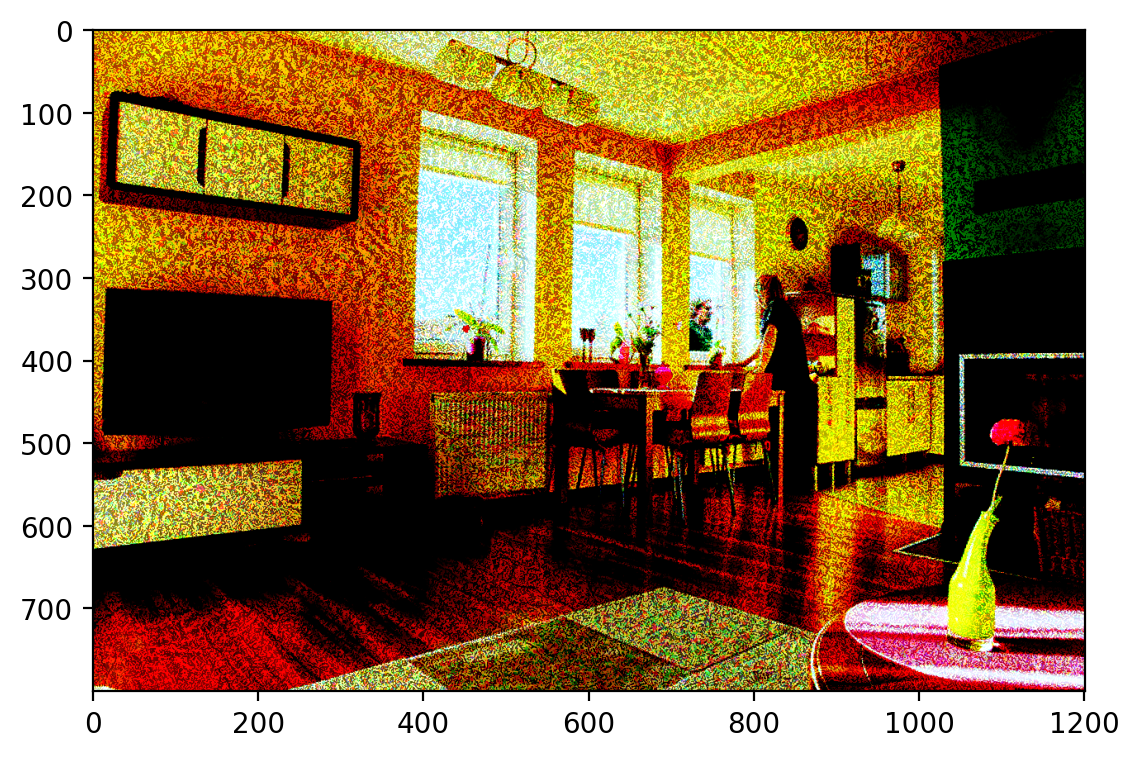

In [ ]:
plt.imshow(perturbed_img[0].detach().cpu().permute(1, 2, 0))